In [1]:
!pip install datasets matplotlib seaborn pandas

In [2]:
from datasets import load_dataset

dataset = load_dataset("nelorth/oxford-flowers")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.85k [00:00<?, ?B/s]

data/train-00000-of-00001-12de94e121bdbe(…):   0%|          | 0.00/303M [00:00<?, ?B/s]

data/test-00000-of-00001-96eeec628415add(…):   0%|          | 0.00/43.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1020 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7169
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1020
    })
})


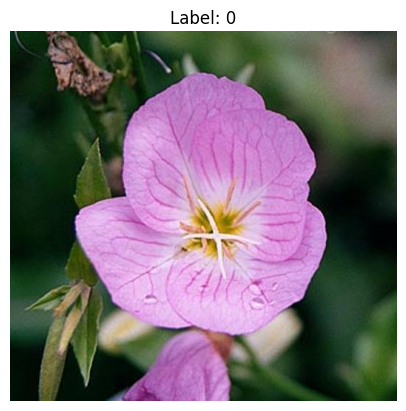

In [3]:
import matplotlib.pyplot as plt

sample = dataset["train"][0]

image = sample["image"]
label = sample["label"]

plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

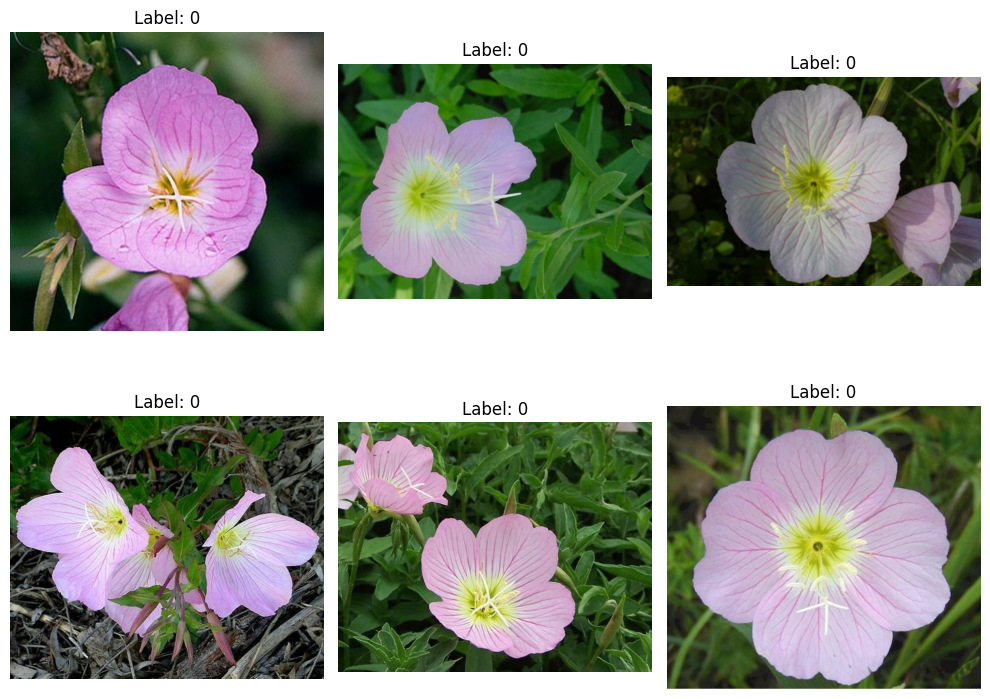

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    sample = dataset["train"][i]
    ax.imshow(sample["image"])
    ax.set_title(f"Label: {sample['label']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
widths = []
heights = []

samples = dataset["train"].select(range(100))

for sample in samples:
    image = sample["image"]
    widths.append(image.size[0])
    heights.append(image.size[1])

print("Average Width:", sum(widths)/len(widths))
print("Average Height:", sum(heights)/len(heights))

Average Width: 617.54
Average Height: 525.46


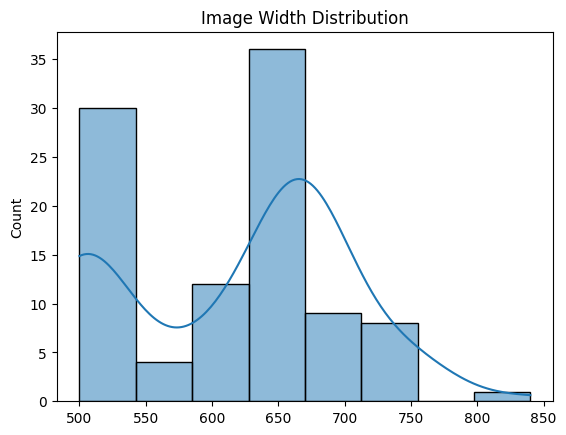

In [9]:
import seaborn as sns

sns.histplot(widths, kde=True)

plt.title("Image Width Distribution")
plt.show()

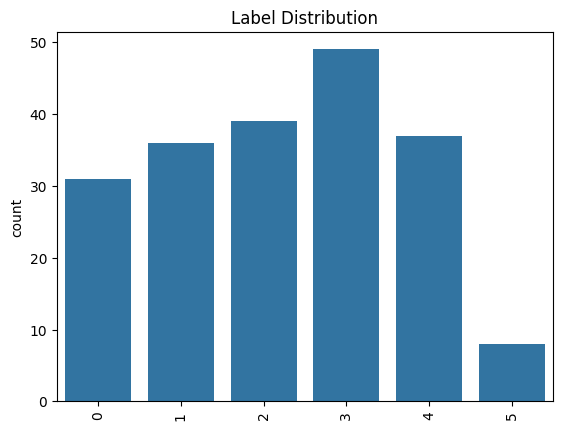

In [11]:
samples = dataset["train"].select(range(200))

labels = [sample["label"] for sample in samples]

sns.countplot(x=labels)

plt.title("Label Distribution")
plt.xticks(rotation=90)

plt.show()

# Image Preprocessing

Before training diffusion models:
- images are resized
- normalized
- converted to tensors

Preprocessing improves:
- training stability
- consistency
- GPU efficiency